In [3]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/25-1/ICV/project

Mounted at /content/drive
/content/drive/MyDrive/25-1/ICV/project


In [2]:
!apt-get update
!apt-get install -y tesseract-ocr
!apt-get install -y tesseract-ocr-kor
!pip install pytesseract pillow

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,683 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,729 kB]
Get:13 https://r2u.stat.illi

In [4]:
import cv2
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import os

# sample_photos 폴더 내 모든 이미지 파일 경로 리스트로 가져오기
photo_folder = './Sample_Photos'
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
sorted_filenames = sorted(os.listdir(photo_folder))
photo_list = [
    os.path.join(photo_folder, fname)
    for fname in sorted_filenames
    if fname.lower().endswith(image_extensions)
]

print(f"총 {len(photo_list)}개의 이미지 파일을 찾았습니다.")

총 9개의 이미지 파일을 찾았습니다.


In [5]:
import pytesseract
from pytesseract import Output
import numpy as np

# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'


def ocr_highlighted_images(highlighted_image_results):
    conf_thresholds = [0, 10, 50]
    psm_modes = {
        "psm6": '--oem 3 --psm 6 -l kor+eng',
        "psm8": '--oem 3 --psm 8 -l kor+eng',
        "psm10": '--oem 3 --psm 10 -l kor+eng'
    }
    all_detected_boxes = []  # 모든 box 정보 저장

    for result in highlighted_image_results:
        highlighted_image = result["highlighted_image"]
        tolerance = result["tolerance"]

        gray = cv2.cvtColor(highlighted_image, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (3, 3), 0.01)
        _, binary = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)
        dilated = cv2.dilate(binary, np.ones((2, 2), np.uint8), iterations=1)

        image_height, image_width = dilated.shape

        for conf_threshold in conf_thresholds:
            for label, config in psm_modes.items():
                results = pytesseract.image_to_data(dilated, output_type=Output.DICT, config=config)
                n_boxes = len(results['level'])
                for i in range(n_boxes):
                    text = results['text'][i].strip()
                    conf = int(results['conf'][i])
                    x = results['left'][i]
                    y = results['top'][i]
                    w = results['width'][i]
                    h = results['height'][i]

                    if (conf > conf_threshold and text != '' and
                        x > 0 and y > 0 and x + w < image_width and y + h < image_height):

                        # box 정보 저장
                        all_detected_boxes.append({
                            "tolerance": tolerance,
                            "psm": label,
                            "conf_threshold": conf_threshold,
                            "x": x,
                            "y": y,
                            "w": w,
                            "h": h,
                            "conf": conf,
                            "text": text
                        })
    return all_detected_boxes

# box 크기 조정 및 줄이기
def color_similar(pixel, target_color, tolerance=30):
    return np.all(np.abs(pixel.astype(int) - target_color.astype(int)) <= tolerance)

In [51]:
# 필요 함수 임포트: ocr_highlighted_images, color_similar
# from your_module import ocr_highlighted_images, color_similar

def extract_target_color(image, crop, target_pixel):
    """
    한 장의 이미지에서 지정된 crop 영역을 잘라내고,
    해당 크롭된 영역 내 지정 픽셀의 RGB 색상(target_color)을 반환합니다.

    Args:
        image (np.ndarray): 원본 이미지 (RGB)
        crop (dict): {'top','bottom','left','right'} 크롭 좌표
        target_pixel (tuple): (y, x) 크롭된 이미지 내 기준 픽셀 좌표

    Returns:
        np.ndarray: target_color (shape=(3,), dtype=int)
    """
    top, bottom = crop['top'], crop['bottom']
    left, right = crop['left'], crop['right']
    cropped = image[top:bottom, left:right]
    y, x = target_pixel
    target_color = cropped[y, x].astype(int)
    return target_color


def make_subtitle_mask_and_box(image, crop, target_color, tolerance):
    """
    한 장의 이미지에서 지정된 crop 영역 내에서
    target_color ± tolerance 범위로 mask를 만들고,
    OCR 후보 박스 및 이후 각종 필터링과 확장을 통해
    전체 이미지 좌표 기준의 mask_bbox와 bbox를 반환합니다.

    Args:
        image (np.ndarray): 원본 이미지 (RGB)
        crop (dict): {'top','bottom','left','right'} 크롭 좌표
        target_color (np.ndarray): 추출된 자막 색상
        tolerance (int): 색상 허용 오차

    Returns:
        dict: {
            'mask_bbox': np.ndarray,  # 전체 이미지 크기의 이진 마스크
            'bbox': tuple or None,    # 전체 이미지 좌표계 바운딩 박스
        }
    """
    # 1) 크롭된 이미지 영역
    top, bottom = crop['top'], crop['bottom']
    left, right = crop['left'], crop['right']
    cropped = image[top:bottom, left:right]

    # 2) 색상 기반 크롭 마스크 생성
    highlighted_images = []
    for tol in range(5, 51, 5):
        # mask/highlight 생성 코드 (tolerance=tol)
        lower = np.clip(target_color - tol, 0, 255)
        upper = np.clip(target_color + tol, 0, 255)
        mask_crop = cv2.inRange(cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR),
                          lower[::-1], upper[::-1])
        highlighted = np.zeros_like(cropped)
        highlighted[mask_crop == 255] = [255,255,255]

        highlighted_images.append({
            'tolerance': tol,
            'highlighted_image': highlighted,
        })

    # 3) OCR 후보 박스 생성
    candidates = ocr_highlighted_images(highlighted_images)

    # 4) color_similar 기반 첫 트리밍
    trimmed = []
    for box in candidates:
        x0, y0, w, h = box['x'], box['y'], box['w'], box['h']
        x_min, y_min = x0, y0
        x_max, y_max = x0 + w, y0 + h
        # 위쪽 트리밍
        for yy in range(y_min, y_max):
            if np.any([color_similar(p, target_color, tolerance=30) for p in cropped[yy, x_min:x_max]]):
                y_min = yy; break
        # 아래쪽 트리밍
        for yy in range(y_max-1, y_min-1, -1):
            if np.any([color_similar(p, target_color, tolerance=30) for p in cropped[yy, x_min:x_max]]):
                y_max = yy + 1; break
        # 왼쪽 트리밍
        for xx in range(x_min, x_max):
            if np.any([color_similar(p, target_color, tolerance=30) for p in cropped[y_min:y_max, xx]]):
                x_min = xx; break
        # 오른쪽 트리밍
        for xx in range(x_max-1, x_min-1, -1):
            if np.any([color_similar(p, target_color, tolerance=30) for p in cropped[y_min:y_max, xx]]):
                x_max = xx + 1; break
        if x_max > x_min and y_max > y_min:
            trimmed.append({'x': x_min, 'y': y_min, 'w': x_max-x_min, 'h': y_max-y_min})

    # 5) 최빈 높이 필터링
    heights = [b['h'] for b in trimmed]
    if heights:
        hist_h, bins_h = np.histogram(heights, bins=20)
        i_h = hist_h.argmax(); h_lo, h_hi = bins_h[i_h], bins_h[i_h+1]
        mode_h = [b for b in trimmed if h_lo <= b['h'] <= h_hi]
    else:
        mode_h = []

    # 6) 최빈 너비 필터링
    x_edges = []
    for b in mode_h:
        x_edges += [b['x'], b['x'] + b['w']]

    if x_edges:
        # 히스토그램 계산
        hist_x, bins_x = np.histogram(x_edges, bins=40)
        # 박스 수
        sample_count = len(x_edges) // 2
        threshold = sample_count / 10

        filtered = []
        for bin_idx, count in enumerate(hist_x):
            if count > threshold:
                bin_left  = bins_x[bin_idx]
                bin_right = bins_x[bin_idx + 1]
                for b in mode_h:
                    x0, x1 = b['x'], b['x'] + b['w']
                    if (bin_left <= x0 < bin_right) or (bin_left <= x1 < bin_right):
                        filtered.append(b)
        # 중복 제거
        mode_xy = list({id(b): b for b in filtered}.values())
    else:
        mode_xy = []

    # 7) 통합 박스 및 gradient 확장
    if not mode_xy:
        return {'mask_bbox': None, 'bbox': None}
    xs = [x for b in mode_xy for x in (b['x'], b['x'] + b['w'])]
    ys = [y for b in mode_xy for y in (b['y'], b['y'] + b['h'])]

    margin = 5
    cx_min = max(0, min(xs) - margin)
    cy_min = max(0, min(ys) - margin)
    cx_max = min(cropped.shape[1], max(xs) + margin)
    cy_max = min(cropped.shape[0], max(ys) + margin)
    #
    gray = cv2.cvtColor(cropped, cv2.COLOR_RGB2GRAY)
    sob_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, 3)
    sob_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, 3)
    grad = np.sqrt(sob_x**2 + sob_y**2)
    max_expand = 40
    gradient_threshold = 60
    et = eb = el = er = 0

    for i in range(1, max_expand):
        y_line = cy_min - i
        if y_line < 0: break
        if grad[y_line, cx_min:cx_max].mean() >= gradient_threshold:
            et = i; break
    for i in range(1, max_expand):
        y_line = cy_max + i
        if y_line >= grad.shape[0]: break
        if grad[y_line, cx_min:cx_max].mean() >= gradient_threshold:
            eb = i; break
    for i in range(1, max_expand):
        x_line = cx_min - i
        if x_line < 0: break
        if grad[cy_min:cy_max, x_line].mean() >= gradient_threshold:
            el = i; break
    for i in range(1, max_expand):
        x_line = cx_max + i
        if x_line >= grad.shape[1]: break
        if grad[cy_min:cy_max, x_line].mean() >= gradient_threshold:
            er = i; break
    cx_min = max(0, cx_min - el)
    cy_min = max(0, cy_min - et)
    cx_max = min(cropped.shape[1], cx_max + er)
    cy_max = min(cropped.shape[0], cy_max + eb)

    # 8) 전체 이미지 좌표로 변환
    x_min_all, y_min_all = cx_min + left, cy_min + top
    x_max_all, y_max_all = cx_max + left, cy_max + top
    bbox = (x_min_all, y_min_all, x_max_all, y_max_all)

    # 9) bbox 영역만 포함하는 mask_bbox 생성
    mask_bbox = np.zeros_like(image[:, :, 0], dtype=np.uint8)
    mask_bbox[y_min_all:y_max_all, x_min_all:x_max_all] = mask_crop[cy_min:cy_max, cx_min:cx_max]

    return {'mask_bbox': mask_bbox, 'bbox': bbox}

In [57]:
crop_list = [
    {"top": 100, "bottom": 300, "left": 100, "right": 1500},
    {"top": 800, "bottom": 900, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 800, "bottom": 950, "left": 100, "right": 1600},
    {"top": 1000, "bottom": 1200, "left": 100, "right": 2450},
    {"top": 1000, "bottom": 1200, "left": 100, "right": 2450}
]
target_pixel_list = [
    (100, 1048),
    (54, 1000),
    (50, 1000),
    (102, 1000),
    (80, 996),
    (80, 700),
    (80, 700),
    (100, 1006),
    (99, 975)
    ]

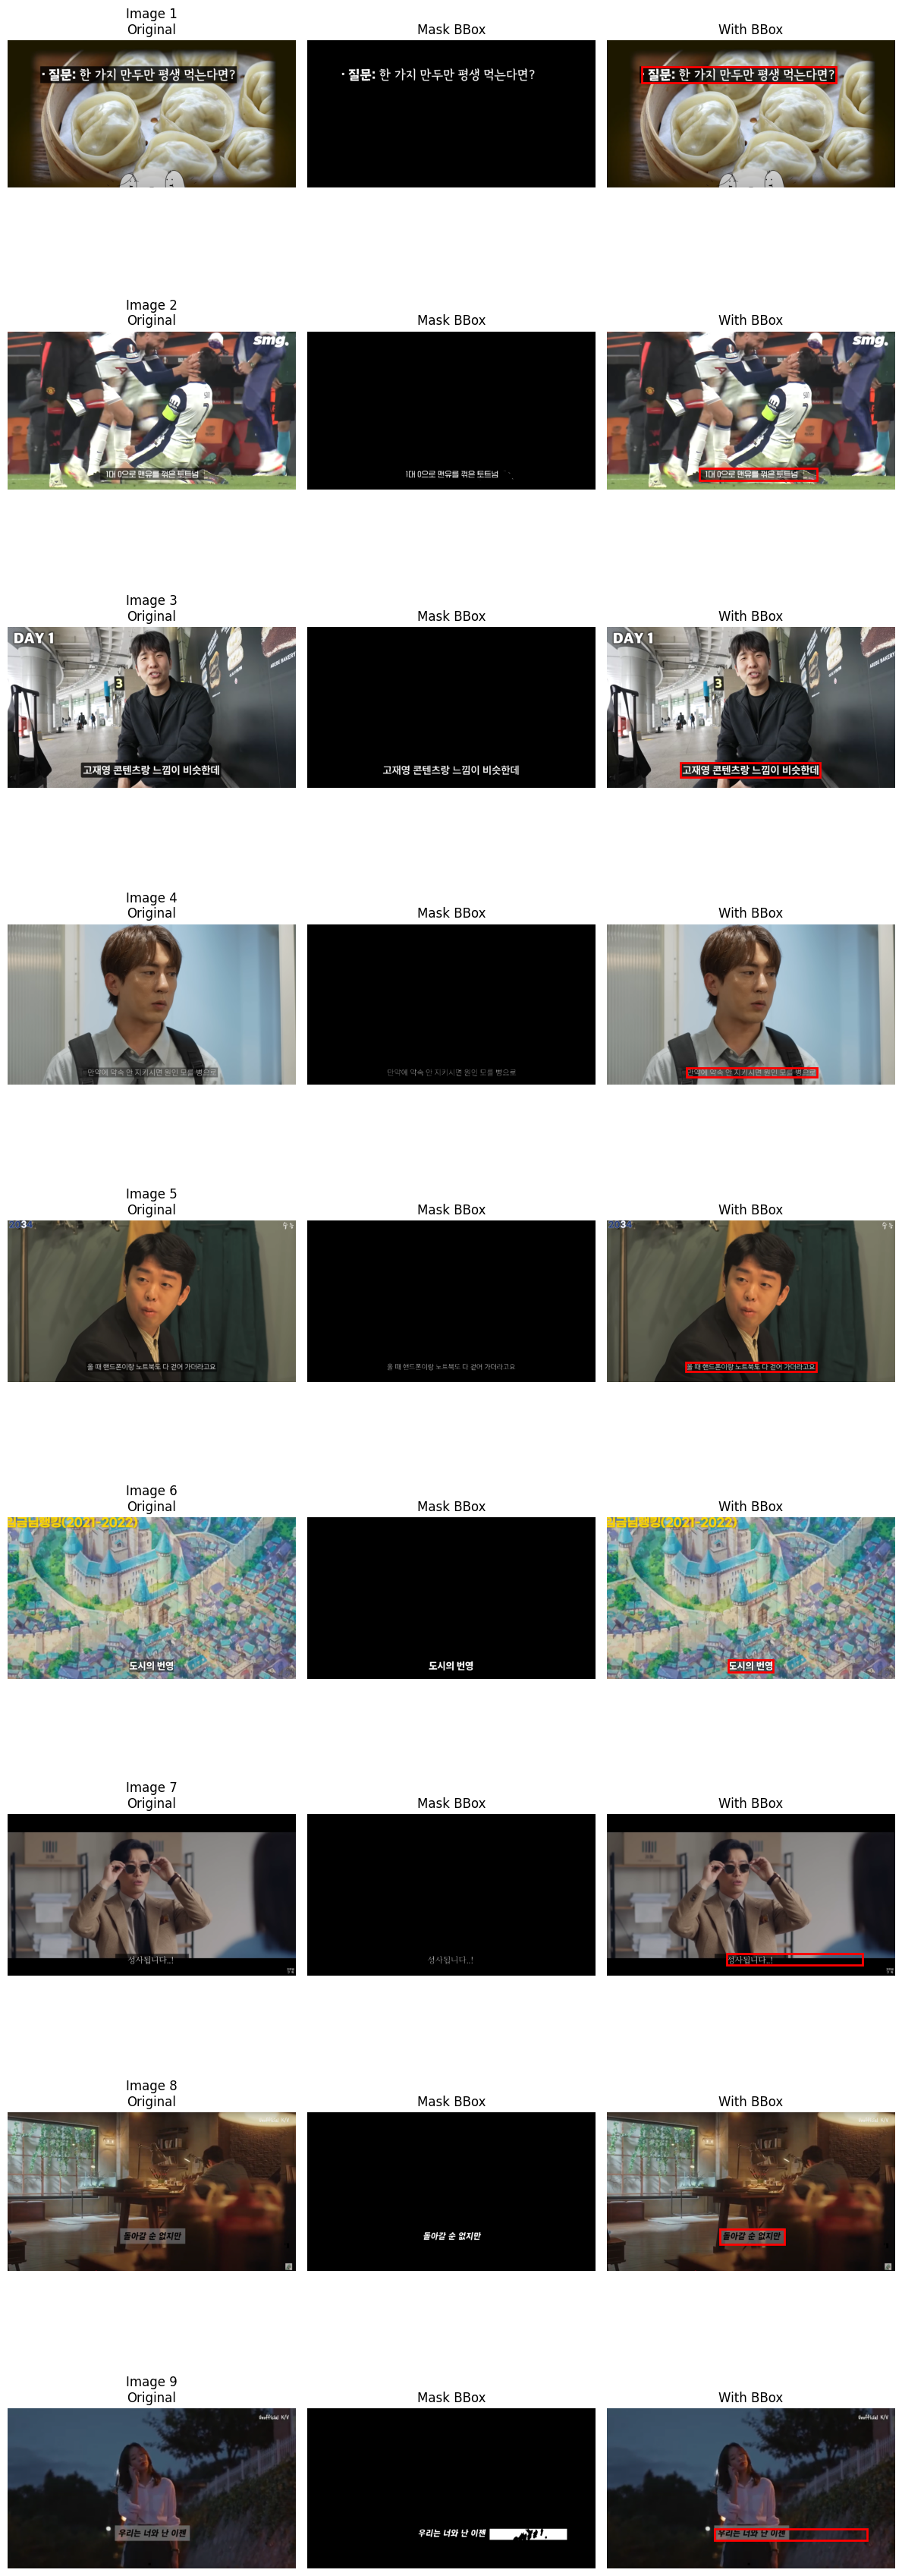

In [56]:
# Assuming extract_target_color and make_subtitle_mask_and_box are already defined in the notebook

num_images = 9
fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

for idx in range(num_images):
    # 1. Load and convert image
    img_path = photo_list[idx]
    img_bgr = cv2.imread(img_path)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Extract target color
    crop = crop_list[idx]
    target_pixel = target_pixel_list[idx]
    target_color = extract_target_color(img, crop, target_pixel)

    # 3. Compute mask_bbox and bbox
    tolerance = 50
    result = make_subtitle_mask_and_box(img, crop, target_color, tolerance)
    mask_bbox = result['mask_bbox']
    bbox = result['bbox']

    # 4. Visualization per row
    ax_orig = axes[idx, 0]
    ax_mask = axes[idx, 1]
    ax_boxed = axes[idx, 2]

    # Original
    ax_orig.imshow(img)
    ax_orig.set_title(f'Image {idx+1}\nOriginal')
    ax_orig.axis('off')

    # Mask
    ax_mask.imshow(mask_bbox, cmap='gray')
    ax_mask.set_title('Mask BBox')
    ax_mask.axis('off')

    # Box overlay
    ax_boxed.imshow(img)
    if bbox is not None:
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             edgecolor='red', facecolor='none', linewidth=2)
        ax_boxed.add_patch(rect)
    ax_boxed.set_title('With BBox')
    ax_boxed.axis('off')

plt.tight_layout()
plt.show()
